# Hybrid CNN-ViT (ConvNeXt) Training on SGFood233

This notebook trains a Hybrid CNN-Transformer model (ConvNeXt) on the SGFood233 dataset.

**Model:** ConvNeXt-Base (ImageNet pretrained)  
**Dataset:** SGFood233 (233 Singaporean food classes, ~210K images)

## Dataset Setup

SGFood233 requires registration from NUS: https://foodlg.comp.nus.edu.sg/

Organize as:
```
data/sgfood233/
├── train/
├── val/
└── test/
```

## 1. Setup and Imports

In [1]:
# Install dependencies (run once)
# !pip install torch torchvision timm pytorch-lightning scikit-learn rich

In [2]:
import torch
import pytorch_lightning as pl
import matplotlib.pyplot as plt
import os
from pathlib import Path

# Import shared utilities
from utils import (
    Config, set_seed, get_train_transforms, get_val_transforms,
    LocalImageDataset, FoodClassifier, create_dataloaders,
    get_trainer_callbacks, save_class_mapping
)

# Set seed for reproducibility
set_seed(Config.SEED)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.8.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 5060 Ti


## 2. Configure Dataset Path

In [3]:
# ============================================================
# UPDATE THIS PATH to your SGFood233 dataset location
# ============================================================
DATASET_ROOT = "../foodsg-233_train_val_split"  # <-- Change this!

# Verify dataset exists
if not os.path.exists(DATASET_ROOT):
    raise FileNotFoundError(
        f"Dataset not found at {DATASET_ROOT}\n"
        f"Please download SGFood233 from https://foodlg.comp.nus.edu.sg/ "
        f"and update DATASET_ROOT"
    )

print(f"Dataset root: {DATASET_ROOT}")
print(f"Contents: {os.listdir(DATASET_ROOT)}")

Dataset root: ../foodsg-233_train_val_split
Contents: ['train', 'val']


## 3. Load SGFood233 Dataset

In [4]:
# Create datasets
print("Loading SGFood233 dataset...")

train_ds = LocalImageDataset(DATASET_ROOT, split='train', transform=get_train_transforms())
val_ds = LocalImageDataset(DATASET_ROOT, split='val', transform=get_val_transforms())

# Extract class info from the training dataset
num_classes = len(train_ds.class_to_idx)
id2label = train_ds.idx_to_class
label2id = train_ds.class_to_idx

print(f"Train samples: {len(train_ds)}")
print(f"Validation samples: {len(val_ds)}")
print(f"Number of classes: {num_classes}")

Loading SGFood233 dataset...
Train samples: 153138
Validation samples: 51167
Number of classes: 233


In [5]:
# Show first 10 class names
class_names = list(label2id.keys())
print(f"\nFirst 10 classes: {class_names[:10]}")


First 10 classes: ['Alcoholic Beverage', 'Apple', 'Apricot', 'Avocados', 'Ban Mian', 'Barley', 'Bee hoon, goreng', 'Bee hoon, soto', 'Bibimbap', 'Blackberry']


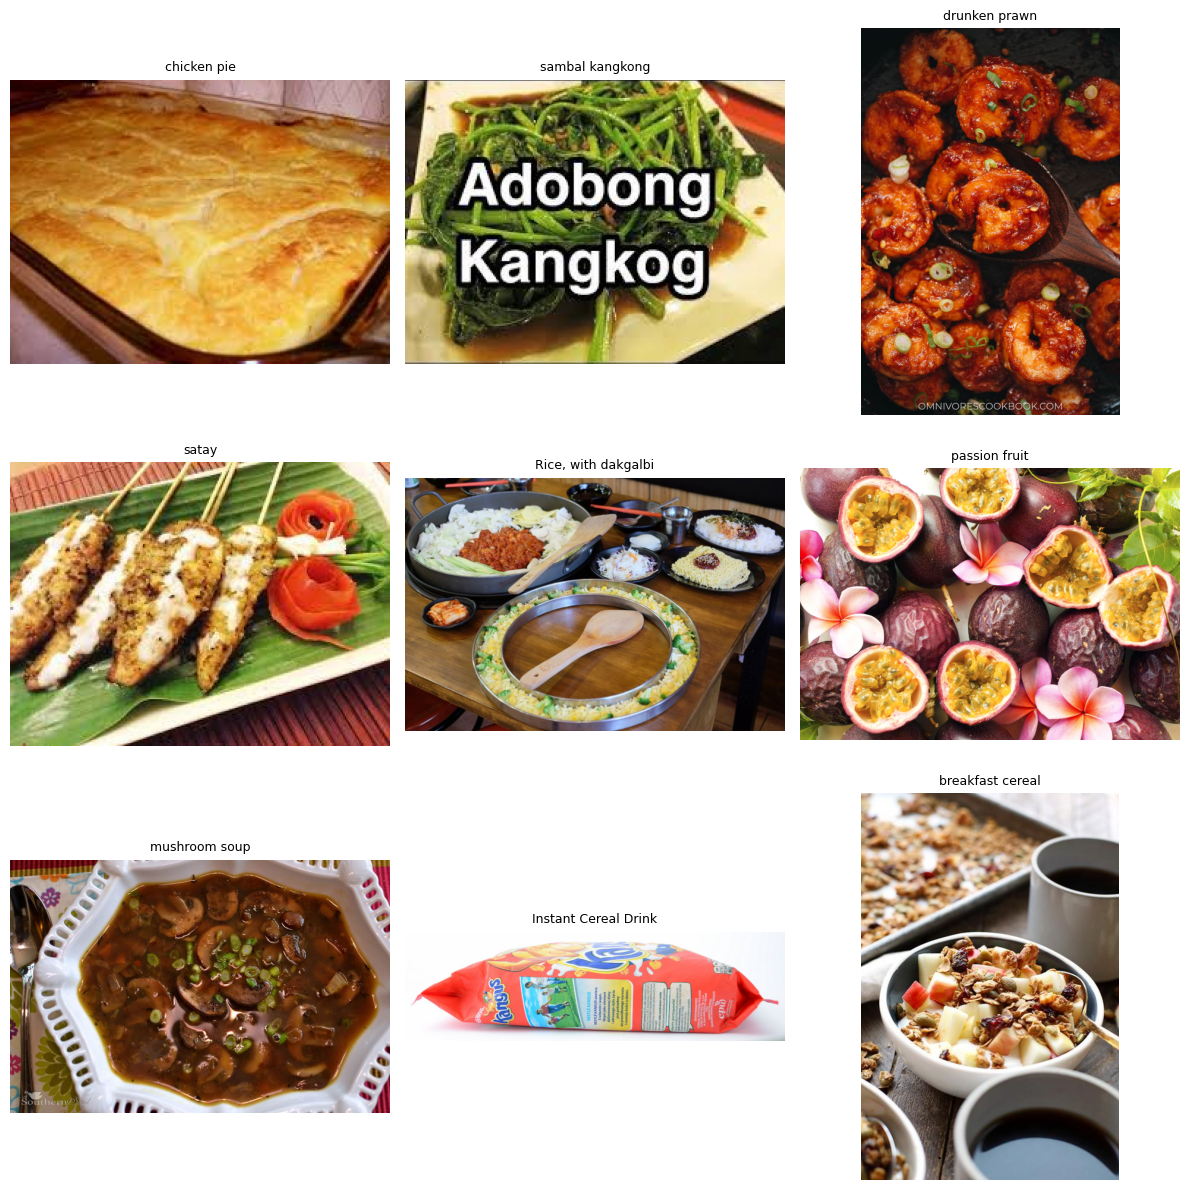

In [6]:
# Visualize sample images
from PIL import Image
import random

plt.figure(figsize=(12, 12))
indices = random.sample(range(len(train_ds)), 9)

for i, idx in enumerate(indices):
    img_path, label = train_ds.samples[idx]
    img = Image.open(img_path)
    plt.subplot(3, 3, i+1)
    plt.imshow(img)
    plt.title(id2label[label], fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()

## 4. Create DataLoaders

In [7]:
# Create dataloaders
train_dl, val_dl = create_dataloaders(train_ds, val_ds)

print(f"Train batches: {len(train_dl)}")
print(f"Val batches: {len(val_dl)}")

Train batches: 2393
Val batches: 800


In [8]:
# Verify batch shape
batch = next(iter(train_dl))
images, labels = batch
print(f"Batch images shape: {images.shape}")
print(f"Batch labels shape: {labels.shape}")

Batch images shape: torch.Size([64, 3, 224, 224])
Batch labels shape: torch.Size([64])


## 5. Initialize Hybrid Model (ConvNeXt)

In [9]:
# Model configuration
MODEL_NAME = Config.MODELS['hybrid']  # convnext_base
EXPERIMENT_NAME = f"sgfood233_{MODEL_NAME}"

print(f"Model: {MODEL_NAME}")
print(f"Number of classes: {num_classes}")
print(f"Learning rate: {Config.LEARNING_RATE}")
print(f"Max epochs: {Config.MAX_EPOCHS}")

Model: convnext_base
Number of classes: 233
Learning rate: 0.0001
Max epochs: 10


In [10]:
# Create model
model = FoodClassifier(
    backbone_name=MODEL_NAME,
    num_classes=num_classes,
    lr=Config.LEARNING_RATE,
    weight_decay=Config.WEIGHT_DECAY,
)

# Print model summary
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 87,805,289
Trainable parameters: 87,805,289


## 6. Training

In [11]:
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from pytorch_lightning.loggers import TensorBoardLogger

# Callbacks
checkpoint_cb = ModelCheckpoint(
    dirpath=f"checkpoints/{EXPERIMENT_NAME}",
    monitor="val_acc",
    mode="max",
    save_top_k=1,
    filename="{epoch:02d}-{val_acc:.4f}",
)

early_stop_cb = EarlyStopping(
    monitor="val_acc",
    mode="max",
    patience=Config.EARLY_STOP_PATIENCE,
    verbose=True,
)

# Logger
logger = TensorBoardLogger("logs", name=EXPERIMENT_NAME)

# Trainer
trainer = pl.Trainer(
    max_epochs=Config.MAX_EPOCHS,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    callbacks=[checkpoint_cb, early_stop_cb],
    logger=logger,
    precision="16-mixed" if torch.cuda.is_available() else 32,
    log_every_n_steps=50,
)

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores


In [12]:
# Train the model
print(f"Starting training for {EXPERIMENT_NAME}...")
trainer.fit(model, train_dl, val_dl)

You are using a CUDA device ('NVIDIA GeForce RTX 5060 Ti') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Starting training for sgfood233_convnext_base...


c:\Users\royli\vscode projects\food image classification\.venv\Lib\site-packages\pytorch_lightning\utilities\model_summary\model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ ConvNeXt         │ 87.8 M │ train │     0 │
│ 1 │ criterion │ CrossEntropyLoss │      0 │ train │     0 │
└───┴───────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 87.8 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 87.8 M                                                                                               
Total estimated model params size (MB): 351                                                                        
Modules in train mode: 466                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

Metric val_acc improved by 0.004 >= min_delta = 0.0. New best score: 0.823


Metric val_acc improved by 0.003 >= min_delta = 0.0. New best score: 0.826


Metric val_acc improved by 0.002 >= min_delta = 0.0. New best score: 0.829


Metric val_acc improved by 0.004 >= min_delta = 0.0. New best score: 0.833


Metric val_acc improved by 0.002 >= min_delta = 0.0. New best score: 0.835
`Trainer.fit` stopped: `max_epochs=10` reached.


In [13]:
# Print best checkpoint path
print(f"\nBest model checkpoint: {checkpoint_cb.best_model_path}")
print(f"Best validation accuracy: {checkpoint_cb.best_model_score:.4f}")


Best model checkpoint: C:\Users\royli\vscode projects\food image classification\food_classifier_project\checkpoints\sgfood233_convnext_base\epoch=09-val_acc=0.8345.ckpt
Best validation accuracy: 0.8345


## 7. Evaluation

In [ ]:
# Load best model
best_model = FoodClassifier.load_from_checkpoint(
    checkpoint_cb.best_model_path,
    backbone_name=MODEL_NAME,
    num_classes=num_classes,
)
best_model.eval()

# Validate
results = trainer.validate(best_model, val_dl)

# Display results clearly
print(f"\n{'='*40}")
print("Final Validation Results")
print(f"{'='*40}")
print(f"Validation Loss:     {results[0]['val_loss']:.4f}")
print(f"Validation Accuracy: {results[0]['val_acc']:.4f} ({results[0]['val_acc']*100:.2f}%)")
print(f"Macro Accuracy:      {results[0]['val_macro_acc']:.4f} ({results[0]['val_macro_acc']*100:.2f}%)")

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│          val_acc          │    0.8345222473144531     │
│         val_loss          │    0.8451198935508728     │
│       val_macro_acc       │    0.8244601488113403     │
└───────────────────────────┴───────────────────────────┘


Final validation results: [{'val_loss': 0.8451198935508728, 'val_acc': 0.8345222473144531, 'val_macro_acc': 0.8244601488113403}]


In [15]:
# Save class mapping for inference
save_class_mapping(id2label, f"checkpoints/{EXPERIMENT_NAME}/id2label.json")
print(f"Class mapping saved to checkpoints/{EXPERIMENT_NAME}/id2label.json")

Class mapping saved to checkpoints/sgfood233_convnext_base/id2label.json


## 8. Quick Inference Test

True label: Alcoholic Beverage
Predicted: Alcoholic Beverage
Confidence: 100.00%


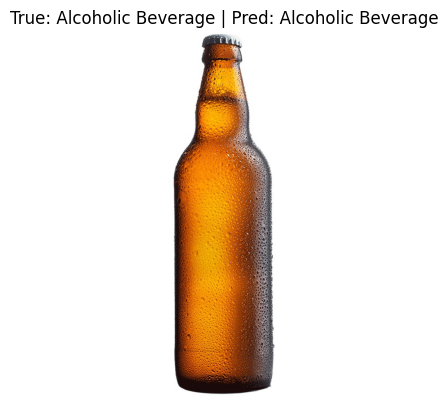

In [16]:
from PIL import Image

# Test inference on a sample
device = "cuda" if torch.cuda.is_available() else "cpu"
best_model.to(device)

# Get a sample from validation set
sample_path, true_label = val_ds.samples[0]
sample_img = Image.open(sample_path).convert("RGB")

# Preprocess
val_tfms = get_val_transforms()
x = val_tfms(sample_img).unsqueeze(0).to(device)

# Inference
with torch.no_grad():
    logits = best_model(x)
    pred = logits.argmax(dim=1).item()
    confidence = torch.softmax(logits, dim=1).max().item()

print(f"True label: {id2label[true_label]}")
print(f"Predicted: {id2label[pred]}")
print(f"Confidence: {confidence:.2%}")

# Show image
plt.imshow(sample_img)
plt.title(f"True: {id2label[true_label]} | Pred: {id2label[pred]}")
plt.axis("off")
plt.show()

---
## Summary

| Metric | Value |
|--------|-------|
| Model | ConvNeXt-Base (Hybrid) |
| Dataset | SGFood233 |
| Best Val Acc | See above |
| Parameters | ~89M |

In [ ]:
# Export to ONNX for deployment
best_model.cpu()
best_model.eval()

dummy_input = torch.randn(1, 3, Config.IMAGE_SIZE, Config.IMAGE_SIZE)
onnx_path = f"checkpoints/{EXPERIMENT_NAME}/sg233convnext.onnx"

torch.onnx.export(
    best_model,
    dummy_input,
    onnx_path,
    export_params=True,
    opset_version=14,
    do_constant_folding=True,
    input_names=["input"],
    output_names=["logits"],
    dynamic_axes={
        "input": {0: "batch_size"},
        "logits": {0: "batch_size"},
    },
)

print(f"ONNX model saved to {onnx_path}")